# Industrial Computer Vision

In [14]:
from matplotlib import pyplot as plt
from numpy import array
from PIL import Image

from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Conv2D # Zum Schärfen unseres Bildes
from tensorflow.keras.layers import MaxPool2D # Zum "Einkochen unserer Bilder"
from tensorflow.keras.layers import Dense, Input, Flatten

from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RandomBrightness, RandomFlip, RandomZoom

from tensorflow.random import set_seed

set_seed(123)

## Look into images

Hier haben wir uns mit unserem Datenmaterial auseinandergesetzt. Wir haben die `imread`-Methode benutzt, um ein Bild zu laden und `imshow` um dieses Bild anschließend darzustellen. Hier haben wir die drei Kanäle des Bildes (Red, Green, und Blue) einzeln dargestellt. Jede dieser Farbschichten ist eine Matrix mit Werten, welche die Sättigung des Bildes in der jeweiligen Farbe beschreiben.

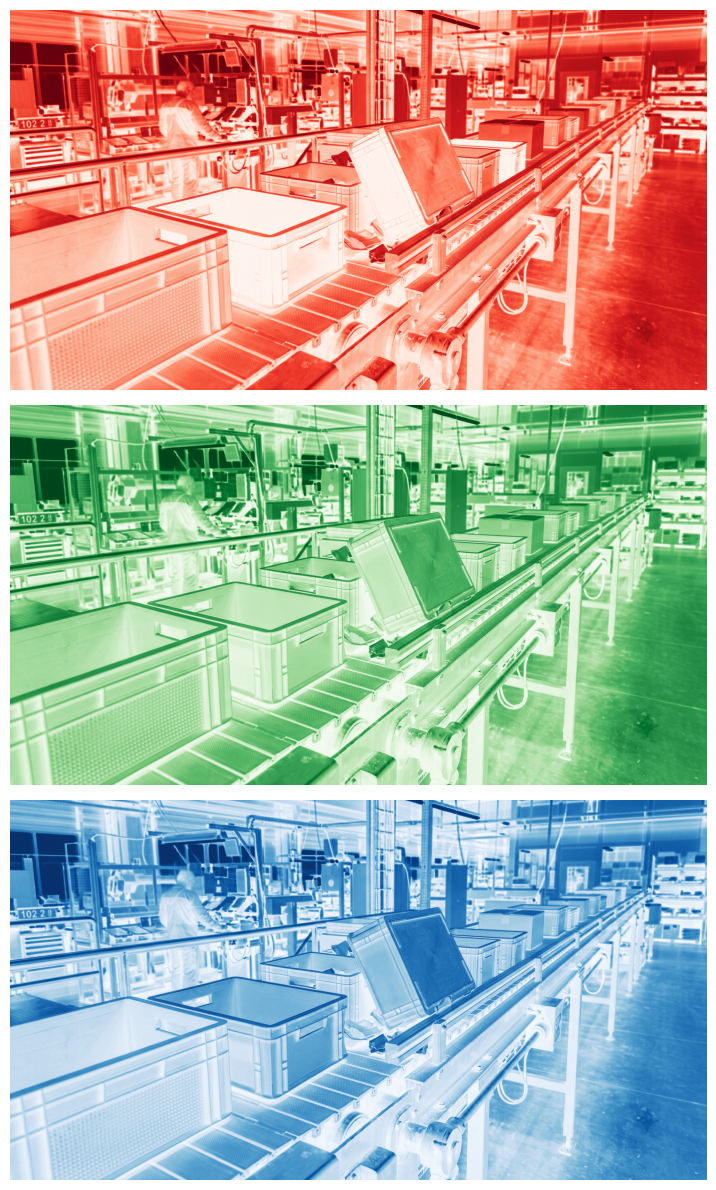

In [2]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(8,12))
ax[0].imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,0], cmap="Reds")
ax[0].set_axis_off()
ax[1].imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,1], cmap="Greens")
ax[1].set_axis_off()
ax[2].imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,2], cmap="Blues")
ax[2].set_axis_off()
plt.tight_layout()
plt.show()

## Load Data

In [3]:
training_data = image_dataset_from_directory(
    "../data",
    image_size=(224, 224),
    batch_size=3,
    seed=123
)

Found 12 files belonging to 3 classes.


In [4]:
training_data.class_names

['empty', 'free', 'jammed']

In [5]:
for images, labels in training_data.take(10):
    print(labels)
    print(images.shape)

tf.Tensor([0 1 1], shape=(3,), dtype=int32)
(3, 224, 224, 3)
tf.Tensor([1 1 2], shape=(3,), dtype=int32)
(3, 224, 224, 3)
tf.Tensor([1 2 2], shape=(3,), dtype=int32)
(3, 224, 224, 3)
tf.Tensor([2 2 1], shape=(3,), dtype=int32)
(3, 224, 224, 3)


## Create Model

In [6]:
model = Sequential()
model.add(Input(shape=(224, 224, 3)))

# Image Augmentation
#model.add(RandomFlip())
#model.add(RandomZoom(0.2))
#model.add(RandomBrightness(-0.2))

# Bildverarbeitung
model.add(Conv2D(24, kernel_size=3, activation="relu"))
model.add(MaxPool2D(pool_size=2))
model.add(Conv2D(12, kernel_size=3, activation="relu"))
model.add(MaxPool2D(pool_size=2))
model.add(Flatten())

# Klassifizierung
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(3, activation="softmax"))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 12)   │         2,604 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 34992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,239,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,243,023 (8.56 MB)

 Trainable params: 2,243,023 (8.56 MB)

 Non-trainable params: 0 (0.00 B)

## Model Nutzen

In [8]:
img = plt.imread("../data/empty/image_06.jpeg")

img_pil = Image.fromarray(img)
img_arr = array(img_pil.resize((224, 224)))/256
img_arr = img_arr.reshape(1, 224, 224, 3)

model.predict(img_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.2783646 , 0.34320974, 0.37842563]], dtype=float32)

## Model Training

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

In [10]:
log = model.fit(training_data, epochs=15, verbose=1)

Epoch 1/15


/Users/michaelkohlegger/Documents/GitHub/industrial_computing_dibse_26/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 690.6462
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 564.1762
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 132.5589
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 53.5895
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 10.3898
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.7798    
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2926
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3196    
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0302
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2018
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0482
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0864
Epoch 13/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0112    
Epoch 14/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1327
Epoch 15/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0764    


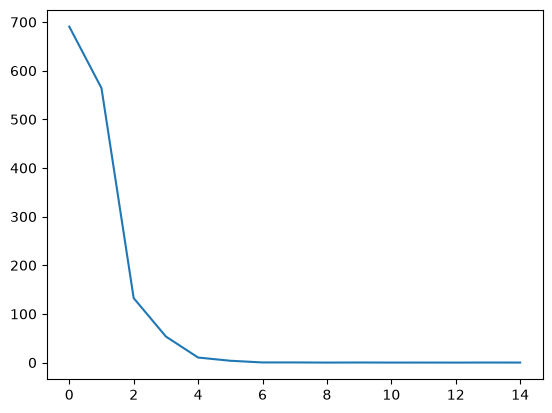

In [11]:
plt.plot(log.history["loss"])

## Model ausprobieren

In [12]:
img = plt.imread("../data/free/image_01.jpeg")

img_pil = Image.fromarray(img)
img_arr = array(img_pil.resize((224, 224)))
img_arr = img_arr.reshape(1, 224, 224, 3)

model.predict(img_arr).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


np.int64(1)

In [13]:
training_data.class_names

['empty', 'free', 'jammed']

## Model serialisieren

In [20]:
model.save("../api/model_cnn.keras")